# Chapter 5: Advanced Parametric vs The ML Floor

We now compare the advanced VIX-Scaled Student-T (which learns VIX elasticity via MLE) against the Wide & Deep Neural Network. 
Both models are tested on the ARKK dataset using a rigorous walk-forward backtest.

We measure:
1. **CRPS (Sharpness)**: Lower is better.
2. **Block K-S Failure Rate (Calibration)**: What percentage of 60-day windows fail the K-S test? (Lower is better).

In [216]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

from datetime import date
import pandas as pd
import numpy as np

from src.data.data_loader import fetch_asset_data
from src.features.features import create_features

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.evaluation.metrics import block_ks_test

from src.models.tf_neural_networks import train_expanding_window_model
from src.data.synthetic import generate_student_t_garch


from scipy.optimize import minimize
from scipy.stats import norm, t
import tensorflow as tf

import tensorflow_probability as tfp
tfd = tfp.distributions

import matplotlib.pyplot as plt
import seaborn as sns

## Functions

In [217]:

def plot_results(pit_values_test_total, dates_test_total, pred_mu_test_total, pred_sigma_test_total, pred_nu_test_total):
    # Set up the Dashboard
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 6))

    # --- PANEL 2: Out-of-Sample PIT Histogram ---
    axes[0, 0].hist(pit_values_test_total, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
    axes[0, 0].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform U(0,1)")
    axes[0, 0].set_title("Out-of-Sample PIT Calibration (Test Set)", fontweight='bold')
    axes[0, 0].set_xlabel("Probability Integral Transform (PIT)")
    axes[0, 0].set_ylabel("Density")
    axes[0, 0].set_ylim(0, 1.5)
    axes[0, 0].legend()

    # --- Plot 2: Parameter Accuracy (Mu) ---
    # A perfect model will align all points on the red dashed 45-degree line
    axes[0, 1].scatter(dates_test_total, pred_mu_test_total, alpha=0.5, color="purple")
    # axes[0, 1].plot([min(true_mu_test), max(true_mu_test)], [min(true_mu_test), max(true_mu_test)], 'r--', lw=2) 
    axes[0, 1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel("True Input Mu")
    axes[0, 1].set_ylabel("Network Predicted Mu")

    # --- Plot 3: Parameter Accuracy (Sigma) ---
    axes[1, 0].scatter(dates_test_total, pred_sigma_test_total, alpha=0.5, color="teal")
    # axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
    axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel("True Input Sigma")
    axes[1, 0].set_ylabel("Network Predicted Sigma")

    # --- Plot 3: Parameter Accuracy (Sigma) ---
    axes[1, 1].scatter(dates_test_total, pred_nu_test_total, alpha=0.5, color="teal")
    # axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
    axes[1, 1].set_title("Parameter Tracking: Degree Freedom (nu)", fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel("True Input Sigma")
    axes[1, 1].set_ylabel("Network Predicted Sigma")

    plt.tight_layout()
    plt.show()


In [218]:
def read_data_features(ticker, start_date, end_date):
    print(f"Fetching {ticker} data...")
    df_asset = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])

    print("Fetching VIX data...")
    df_vix_raw = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
    # Adjust VIX to be daily standard deviation in percentage points
    df_vix = (df_vix_raw[['prices']] / np.sqrt(252)) * 100
    df_vix.columns = ['VIX']

    # Apply custom feature engineering
    window_size_long = 22 * 6
    # window_size_long = 22 * 12

    df_features = create_features(df_asset, df_vix, window_size_long, n_lags=3)
    df_features['vix_ratio'] = df_features['VIX'] / df_features['VIX'].rolling(window_size_long).mean()

    df_features['ret_1_nu'] = 4 + (6 / df_features['ret_1_kurt'])
    df_features.loc[df_features['ret_1_nu'] > 30, 'ret_1_nu'] = 30
    df_features.loc[df_features['ret_1_nu'] < 2, 'ret_1_nu'] = 2

    # vix_mean_train  = np.mean(past_vix_lagged)
    # vix_ratio_train = past_vix_lagged / vix_mean_train

    window_size_short = int(22 / 2)
    df_features_st = create_features(df_asset, df_vix, window_size_short, n_lags=1)
    df_features_st.dropna(inplace=True)
    df_features_st = df_features_st.astype('float32')
    df_features_st = df_features_st[['ret_1_mean', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew']]
    df_features_st.columns = ['ret_1_mean_st', 'ret_1_std_st', 'ret_1_kurt_st', 'ret_1_skew_st']

    df_features = pd.concat([df_features, df_features_st], axis=1)
    df_features.dropna(inplace=True)
    df_features = df_features.astype('float32')
    return df_features


In [219]:
def extract_array(df_features, df_y):
    loc = df_features['ret_1_mean'].values
    scale = df_features['ret_1_std'].values
    df = df_features['ret_1_nu'].values
    vix_ratio = df_features['vix_ratio'].values
    ret = df_y.values
    data = {'loc': loc, 'scale': scale, 'df': df, 'vix_ratio': vix_ratio, 'ret': ret}
    return data

def extract_df_nn(df_features, columns_linear, columns_deep):
    df_X_linear = df_features[columns_linear]
    df_X_deep = df_features[columns_deep] if len(columns_deep) > 0 else None
    df_y = df_features['returns']

    return df_X_linear, df_X_deep, df_y

def run_baseline(data_train, last_optimal_beta, cold_start ):
    
    vix_ratio_train = data_train['vix_ratio']
    scale_train = data_train['scale']
    loc_train = data_train['loc']
    ret_train = data_train['ret']

    def objective_function(beta):
        b = beta[0]
        # Manual bounds penalty for Nelder-Mead (no native bounds support)
        if b < -0.5 or b > 5.0:
            return 1e9

        # Factor normalization: keeps overall scale from inflating
        vix_factor = vix_ratio_train ** b
        vix_factor = vix_factor / np.mean(vix_factor)

        s_adj = np.clip(scale_train * vix_factor, 1e-6, 100.0)
        nll   = -np.sum(t.logpdf(ret_train, df=df_train, loc=loc_train, scale=s_adj))
        return 1e9 if (np.isnan(nll) or np.isinf(nll)) else nll

    # Warm-start: escape the zero-trap on first iteration
    start_guess = last_optimal_beta if last_optimal_beta > 0.05 else 0.5
    maxiter     = 200 if cold_start else 30
    cold_start  = False

    try:
        res          = minimize(
            objective_function,
            x0=[start_guess],
            method='Nelder-Mead',
            options={'maxiter': maxiter, 'disp': False},
        )
        optimal_beta = np.clip(res.x[0], -0.5, 5.0)
        last_optimal_beta = optimal_beta
    except Exception:
        optimal_beta = last_optimal_beta

    return optimal_beta

def backtesting_baseline(data_test, optimal_beta):

    vix_ratio_test = data_test['vix_ratio']
    scale_test = data_test['scale']
    loc_test = data_test['loc']
    df_test = data_test['df']
    ret_test = data_test['ret']

    # Forecast tomorrow with factor normalization applied
    pred_factor = (vix_ratio_test ** optimal_beta).astype('float32')

    historical_factor_mean = np.mean(vix_ratio_test ** optimal_beta)
    pred_factor_normalized = pred_factor / historical_factor_mean

    scale_pred = np.clip(scale_test * pred_factor_normalized, 1e-6, 100.0).astype('float32')

    pred_mu_flat = tf.reshape(loc_test, [-1])
    pred_sigma_flat = tf.reshape(scale_pred, [-1])
    pred_nu_flat = tf.reshape(df_test, [-1])
    
    y_test_flat = tf.reshape(ret_test, [-1])
    test_dist = tfd.StudentT(
        df=pred_nu_flat, 
        loc=pred_mu_flat, 
        scale=pred_sigma_flat
    )

    backtesting_results = {'pit_values': test_dist.cdf(y_test_flat).numpy()}
    backtesting_results['mu'] = pred_mu_flat
    backtesting_results['sigma'] = pred_sigma_flat
    backtesting_results['nu'] = pred_nu_flat

    return backtesting_results


## 1. Data Fetching & Feature Engineering

In [229]:
# ticker = 'ARKK'
# ticker = 'USO'
# ticker = 'USDCLP=X'
ticker = 'BTC-USD'
ticker = 'SQM-B.SN'
# ticker = 'VAPORES.SN'

start_date = date(2010, 12, 31)
end_date = date(2025, 12, 31)

df_features = read_data_features(ticker, start_date, end_date)

columns_linear = ['ret_1_mean', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew', 'ret_1_mean_st', 'ret_1_std_st', 'vix_ratio', 'VIX']
# columns_deep = ['VIX', 'ret_1', 'ret_2', 'ret_3']
columns_deep = ['vix_ratio']

test_window = 22
porcentage_train = 0.70
epochs = 500

last_optimal_beta = 0.5
cold_start  = True

Fetching SQM-B.SN data...
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Fetching VIX data...
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [230]:
dates_test = []
pred_mu_result = {'baseline': [], 'neural-network': []}
pred_sigma_result = {'baseline': [], 'neural-network': []}
pred_nu_result = {'baseline': [], 'neural-network': []}
pit_values_result = {'baseline': [], 'neural-network': []}

## 2. Advanced Parametric: VIX-Scaled Student-T

In [231]:
from src.models.tf_neural_networks import LinearStudentTNet, WideAndDeepStudentTNet, nll_loss_fn

def initializate_nn_model(columns_linear, model_class, lr, columns_deep=[]):
    if model_class == 'Linear':
        model = LinearStudentTNet()
    elif model_class == 'WideAndDeep':
        model = WideAndDeepStudentTNet()
    else:
        raise ValueError("model_class must be 'Linear' or 'WideAndDeep'")
        
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    # Initialize model weights by calling it on dummy data
    num_linear_features = len(columns_linear) 
    dummy_x_linear = tf.zeros((1, num_linear_features))

    num_deep_features = len(columns_deep)

    if num_deep_features == 0:
        model(dummy_x_linear)
    else:
        dummy_x_deep = tf.zeros((1, num_deep_features))
        model((dummy_x_linear, dummy_x_deep))

    if num_deep_features == 0:
        input_signature = [
            tf.TensorSpec(shape=[None, num_linear_features], dtype=tf.float32),
            tf.TensorSpec(shape=[None], dtype=tf.float32) # y is 1D series
        ]
    else:
        input_signature = [
            tf.TensorSpec(shape=[None, num_linear_features], dtype=tf.float32),
            tf.TensorSpec(shape=[None], dtype=tf.float32), # y is 1D series
            tf.TensorSpec(shape=[None, num_deep_features], dtype=tf.float32)
        ]

    @tf.function(input_signature=input_signature)
    def train_step(X_lin_batch, y_batch, X_deep_batch=None):
        with tf.GradientTape() as tape:
            if X_deep_batch is not None:
                mu, sigma, nu = model((X_lin_batch, X_deep_batch))
            else:
                mu, sigma, nu = model(X_lin_batch)
            loss = nll_loss_fn(mu, sigma, nu, y_batch)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    return train_step, model

# Test results
def backtesting_neural_networks(X_linear_test, X_deep_test, y_test, model):

    if X_deep_test is not None:
        pred_mu_test, pred_sigma_test, pred_nu_test = model((X_linear_test, X_deep_test))
    else:
        pred_mu_test, pred_sigma_test, pred_nu_test = model(X_linear_test)

    
    pred_mu_flat = tf.reshape(pred_mu_test, [-1])
    pred_sigma_flat = tf.reshape(pred_sigma_test, [-1])
    pred_nu_flat = tf.reshape(pred_nu_test, [-1])
    
    y_test_flat = tf.reshape(y_test, [-1])
    test_dist = tfd.StudentT(
        df=pred_nu_flat, 
        loc=pred_mu_flat, 
        scale=pred_sigma_flat
    )
    backtesting_results = {'pit_values': test_dist.cdf(y_test_flat).numpy()}
    backtesting_results['mu'] = pred_mu_flat
    backtesting_results['sigma'] = pred_sigma_flat
    backtesting_results['nu'] = pred_nu_flat

    return backtesting_results

    # pit_values_list.append(test_dist.cdf(y_test_flat).numpy())
    
# is_first_window = True

In [ ]:

def run_neural_networks(df_X_linear_train, df_X_deep_train, df_y_train, current_epochs, train_step):
    X_linear_train = tf.convert_to_tensor(df_X_linear_train.to_numpy(), dtype=tf.float32)
    X_deep_train = tf.convert_to_tensor(df_X_deep_train.to_numpy(), dtype=tf.float32) if df_X_deep_train is not None else None
    y_train = tf.convert_to_tensor(df_y_train.to_numpy(), dtype=tf.float32)
    
    for epoch in range(current_epochs):
        # print(f"Epoch {epoch+1}/{current_epochs} - ", end="")
        # print(X_linear_train.shape, X_deep_train.shape, y_train.shape)
        loss = train_step(X_linear_train, y_train, X_deep_train)
        if epoch % 100 == 0 or epoch == current_epochs - 1:
            print(f"Epoch {epoch:03d} | NLL Loss: {loss.numpy():.4f}")
            



# X_linear_test = tf.convert_to_tensor(df_X_linear_test.to_numpy(), dtype=tf.float32)
# X_deep_test = tf.convert_to_tensor(df_X_deep_test.to_numpy(), dtype=tf.float32) if df_X_deep_test is not None else None
# y_test = tf.convert_to_tensor(df_y_test.to_numpy(), dtype=tf.float32)
    

is_first_window = False

current_epochs = 501
# model_class = 'Linear'
model_class = 'WideAndDeep'
lr = 0.015
n_train = int(porcentage_train * len(df_features))

train_step, model = initializate_nn_model(columns_linear, model_class, lr, columns_deep=columns_deep)

while n_train < len(df_features):
    
    df_features_train = df_features.iloc[:n_train]
    df_X_linear_train, df_X_deep_train, df_y_train = extract_df_nn(df_features_train, columns_linear, columns_deep)
    
    df_features_test = df_features.iloc[n_train:n_train + test_window]
    df_X_linear_test, df_X_deep_test, df_y_test = extract_df_nn(df_features_test, columns_linear, columns_deep)

    dates_test.append(df_features_test.index)

    data_train = extract_array(df_features_train, df_y_train)
    optimal_beta = run_baseline(data_train, last_optimal_beta, cold_start)
    
    data_test = extract_array(df_features_test, df_y_test)
    baseline_results = backtesting_baseline(data_test, optimal_beta)

    pred_mu_result['baseline'].append(baseline_results['mu'])
    pred_sigma_result['baseline'].append(baseline_results['sigma'])
    pred_nu_result['baseline'].append(baseline_results['nu'])
    pit_values_result['baseline'].append(baseline_results['pit_values'])

    run_neural_networks(df_X_linear_train, df_X_deep_train, df_y_train, current_epochs, train_step)
    if cold_start:
        current_epochs = current_epochs // 2
        cold_start = False
    
    neural_networks_results = backtesting_neural_networks(df_X_linear_test, df_X_deep_test, df_y_test, model)

    pred_mu_result['neural-network'].append(neural_networks_results['mu'])
    pred_sigma_result['neural-network'].append(neural_networks_results['sigma'])
    pred_nu_result['neural-network'].append(neural_networks_results['nu'])
    pit_values_result['neural-network'].append(neural_networks_results['pit_values'])

    n_train += test_window
    

Epoch 000 | NLL Loss: 16.9706
Epoch 100 | NLL Loss: 2.7688
Epoch 200 | NLL Loss: 2.5492
Epoch 300 | NLL Loss: 2.4944
Epoch 400 | NLL Loss: 2.4338
Epoch 500 | NLL Loss: 2.3662
Epoch 000 | NLL Loss: 2.3665
Epoch 100 | NLL Loss: 2.3049
Epoch 200 | NLL Loss: 2.2556
Epoch 249 | NLL Loss: 2.2329
Epoch 000 | NLL Loss: 2.2332
Epoch 100 | NLL Loss: 2.1915
Epoch 200 | NLL Loss: 2.1546
Epoch 249 | NLL Loss: 2.1388
Epoch 000 | NLL Loss: 2.1413
Epoch 100 | NLL Loss: 2.1133
Epoch 200 | NLL Loss: 2.0937
Epoch 249 | NLL Loss: 2.0878
Epoch 000 | NLL Loss: 2.0939
Epoch 100 | NLL Loss: 2.0859
Epoch 200 | NLL Loss: 2.0830
Epoch 249 | NLL Loss: 2.0822
Epoch 000 | NLL Loss: 2.0870
Epoch 100 | NLL Loss: 2.0853
Epoch 200 | NLL Loss: 2.0841
Epoch 249 | NLL Loss: 2.0835
Epoch 000 | NLL Loss: 2.0884
Epoch 100 | NLL Loss: 2.0874
Epoch 200 | NLL Loss: 2.0863
Epoch 249 | NLL Loss: 2.0861
Epoch 000 | NLL Loss: 2.0913
Epoch 100 | NLL Loss: 2.0904
Epoch 200 | NLL Loss: 2.0893
Epoch 249 | NLL Loss: 2.0890
Epoch 000 | N

In [ ]:

dates_test_total = pd.Index(np.concatenate(dates_test)) if dates_test else pd.Index([])

pred_mu_test_total = np.concatenate(pred_mu_result['baseline']) if pred_mu_result['baseline'] else np.array([])
pred_sigma_test_total = np.concatenate(pred_sigma_result['baseline']) if pred_sigma_result['baseline'] else np.array([])
pred_nu_test_total = np.concatenate(pred_nu_result['baseline']) if pred_nu_result['baseline'] else np.array([])
pit_values_test_total = np.concatenate(pit_values_result['baseline']) if pit_values_result['baseline'] else np.array([])

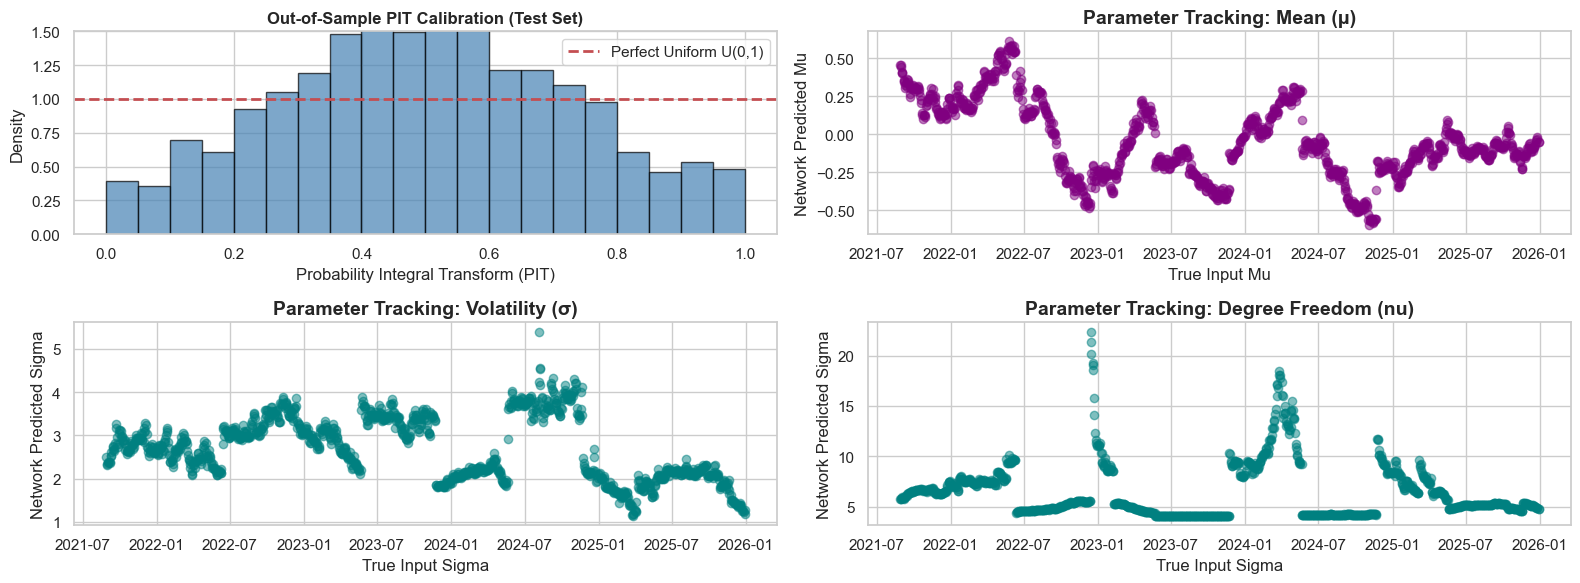

In [ ]:
plot_results(pit_values_test_total, dates_test_total, pred_mu_test_total, pred_sigma_test_total, pred_nu_test_total)
df_pit_values_test_bl = pd.DataFrame(pit_values_test_total, index=dates_test_total, columns=['PIT'])
# block_ks_test(df_pit_values_test['PIT'], block_size=len(df_pit_values_test))

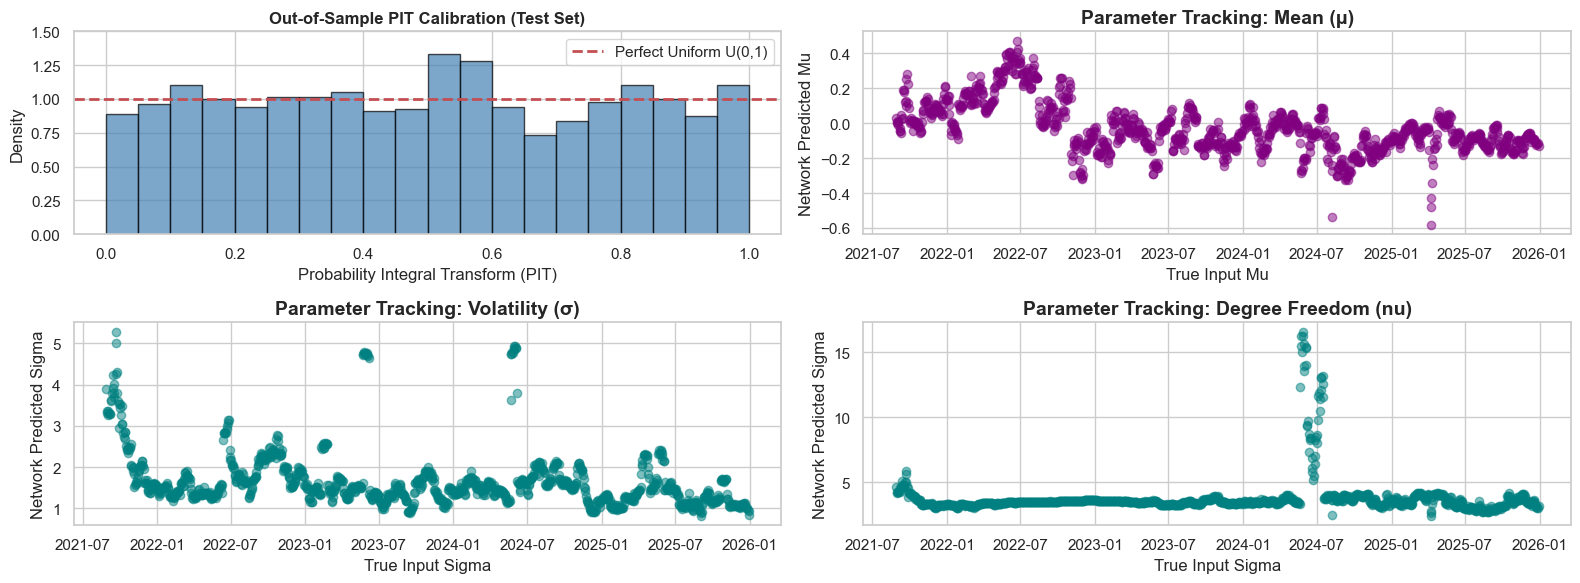

In [ ]:
model_type = 'neural-network'

pred_mu_test_total = np.concatenate(pred_mu_result[model_type]) if pred_mu_result[model_type] else np.array([])
pred_sigma_test_total = np.concatenate(pred_sigma_result[model_type]) if pred_sigma_result[model_type] else np.array([])
pred_nu_test_total = np.concatenate(pred_nu_result[model_type]) if pred_nu_result[model_type] else np.array([])
pit_values_test_total = np.concatenate(pit_values_result[model_type]) if pit_values_result[model_type] else np.array([])
plot_results(pit_values_test_total, dates_test_total, pred_mu_test_total, pred_sigma_test_total, pred_nu_test_total)
df_pit_values_test_nn = pd.DataFrame(pit_values_test_total, index=dates_test_total, columns=['PIT'])

In [ ]:
block_ks_test(df_pit_values_test_nn['PIT'], block_size=22 * 5)



--- INDEPENDENT BLOCK TEST SUMMARY (110-Day Windows) ---
Total Independent Blocks: 10
Blocks Failed (p < 0.05): 1
True Failure Rate:        10.0%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2021-08-27,2022-01-27,0.112268,0.115649,✅ PASSED
1,2022-01-28,2022-07-01,0.073997,0.558197,✅ PASSED
2,2022-07-04,2022-12-02,0.154869,0.009050,❌ FAILED
3,2022-12-05,2023-05-09,0.075740,0.528430,✅ PASSED
4,2023-05-10,2023-10-10,0.089192,0.326168,✅ PASSED
5,2023-10-11,2024-03-14,0.113626,0.107982,✅ PASSED
6,2024-03-15,2024-08-16,0.063877,0.735943,✅ PASSED
7,2024-08-19,2025-01-21,0.075156,0.538341,✅ PASSED
8,2025-01-22,2025-06-25,0.068525,0.654303,✅ PASSED
9,2025-06-26,2025-11-26,0.101662,0.192053,✅ PASSED


In [ ]:
block_ks_test(df_pit_values_test_bl['PIT'], block_size=22 * 5)



--- INDEPENDENT BLOCK TEST SUMMARY (110-Day Windows) ---
Total Independent Blocks: 10
Blocks Failed (p < 0.05): 5
True Failure Rate:        50.0%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2021-08-27,2022-01-27,0.095035,0.256841,✅ PASSED
1,2022-01-28,2022-07-01,0.105559,0.160352,✅ PASSED
2,2022-07-04,2022-12-02,0.097852,0.227555,✅ PASSED
3,2022-12-05,2023-05-09,0.161857,0.005510,❌ FAILED
4,2023-05-10,2023-10-10,0.214414,0.000064,❌ FAILED
5,2023-10-11,2024-03-14,0.111154,0.122273,✅ PASSED
6,2024-03-15,2024-08-16,0.133058,0.036940,❌ FAILED
7,2024-08-19,2025-01-21,0.220756,0.000035,❌ FAILED
8,2025-01-22,2025-06-25,0.100042,0.206592,✅ PASSED
9,2025-06-26,2025-11-26,0.209916,0.000099,❌ FAILED


## 3. The Machine Learning Floor